# The `@algo` API: Advanced Event-Driven Strategies

This notebook introduces the `@algo` decorator -- the **advanced API** for quants who want
fine-grained control over the event loop.

The two previous notebooks used `SimpleAlgo` with hook methods like `on_auction_open`
and `on_bar`. This works well for straightforward strategies. The `@algo` API is the next
step: a single `async for` loop that receives **every market event in order**, letting you
write complex strategies as clean sequential logic.

By the end of this notebook you will:
- Understand when to choose `@algo` over `SimpleAlgo`
- Know all seven event types and their attributes
- Write a DA price-logger algo with `@algo`
- Build an IDC spread scalper step by step using the event stream
- Access signals from within an event handler
- Run a backtest with `@algo` and interpret the results

**Prerequisites:** `backtester_walkthrough.ipynb` and `idc_and_metrics_walkthrough.ipynb`


In [6]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

# nest_asyncio allows the @algo async engine to run inside Jupyter's event loop.
# Without this, BacktestEngine with an @algo function raises a RuntimeError.
import nest_asyncio
nest_asyncio.apply()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date, timedelta
from decimal import Decimal

FIXTURES_DIR = Path("../tests/fixtures")
IDC_DATA_DIR = FIXTURES_DIR / "nordpool"   # contains idc_events/NO1_2026_03.parquet
DA_DATA_DIR  = FIXTURES_DIR               # contains da_prices.parquet

print("Fixture directories:")
print(f"  IDC: {IDC_DATA_DIR.resolve()}")
print(f"  DA:  {DA_DATA_DIR.resolve()}")
print("\nAll paths exist:", IDC_DATA_DIR.exists() and DA_DATA_DIR.exists())

Fixture directories:
  IDC: /Users/tommedhurst/Source/GitHub/nexa-backtest/tests/fixtures/nordpool
  DA:  /Users/tommedhurst/Source/GitHub/nexa-backtest/tests/fixtures

All paths exist: True


## 1. `SimpleAlgo` vs `@algo` -- Two APIs, One Interface

Both APIs use the same `TradingContext` and produce the same `BacktestResult`.
The engine detects which style you are using and routes events accordingly.

| | `SimpleAlgo` | `@algo` |
|--|--|--|
| **Style** | Class with overridden hook methods | Async function with a single event loop |
| **Entry points** | One method per event type (`on_bar`, `on_fill`, ...) | One `async for` loop handles all events |
| **State** | Instance attributes (`self.threshold`) | Local variables |
| **Signal access** | `subscribe_signal()` + `on_signal` hook | `ctx.get_signal()` anywhere in the loop |
| **Best for** | Straightforward strategies, quick experiments | Complex strategies, cross-event logic |

### When to use `@algo`

Choose `@algo` when your strategy:
- Needs to react to **individual `MarketDataUpdate` events** -- each order book change
  (not available in `SimpleAlgo`)
- Has **state that spans multiple event types** (e.g. count fills since the last bar)
- Reads better as a **top-down sequential flow** rather than scattered hook methods


## 2. The Event Type Hierarchy

The `@algo` event stream delivers seven event types. All inherit from `MarketEvent`, which
provides `timestamp` and `product_id` on every event.

The chart below is a useful reference while writing `@algo` strategies.


In [7]:
# All event types live in nexa_backtest.types
from nexa_backtest.types import (
    MarketEvent,        # base class (timestamp, product_id)
    MarketDataUpdate,   # IDC: change to the historical order book
    HistoricalTrade,    # IDC: a trade that occurred in historical data
    GateClosureWarning, # DA + IDC: gate closure approaching
    GateClosureEvent,   # DA + IDC: gate has now closed
    SignalUpdate,       # signals: a signal value changed (see note in section 8)
    BarEvent,           # DA + IDC: MTU boundary; also fires for DA auction opens
    FillEvent,          # all: one of your orders was filled
    CancelEvent,        # all: one of your orders was cancelled
)

print("All event types imported successfully.")

All event types imported successfully.


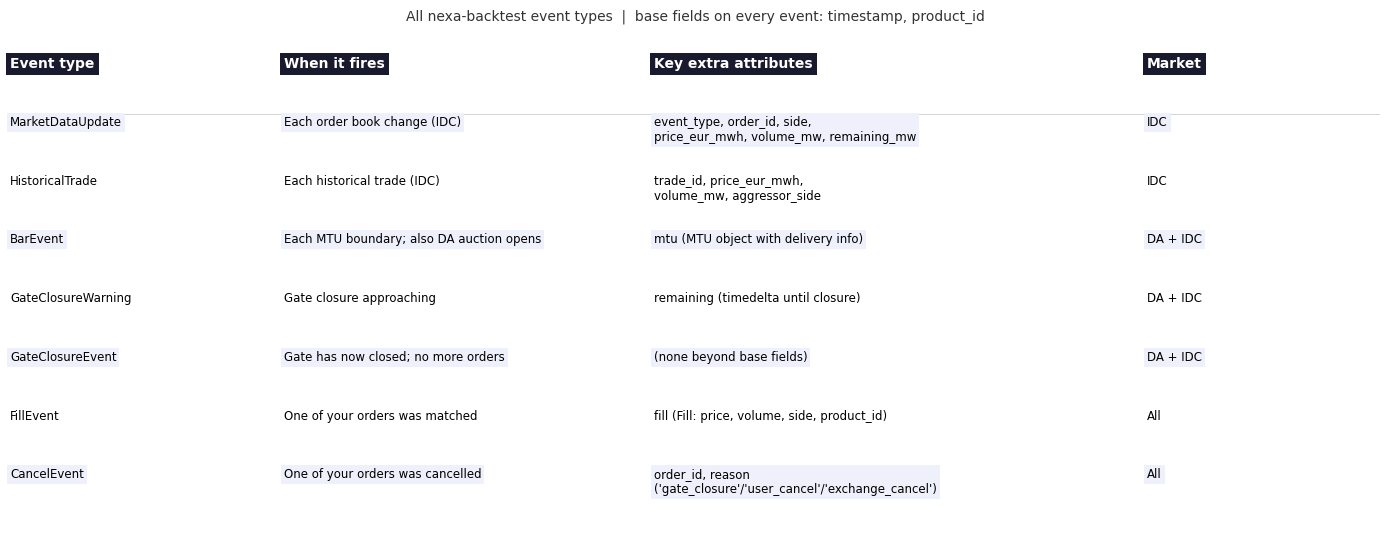

In [8]:
# Visualise the event type hierarchy as a reference table.
# This is a useful reference when writing @algo strategies.
fig, ax = plt.subplots(figsize=(14, 5.5))
ax.axis("off")

headers = ["Event type", "When it fires", "Key extra attributes", "Market"]
rows = [
    ["MarketDataUpdate",
     "Each order book change (IDC)",
     "event_type, order_id, side,\nprice_eur_mwh, volume_mw, remaining_mw",
     "IDC"],
    ["HistoricalTrade",
     "Each historical trade (IDC)",
     "trade_id, price_eur_mwh,\nvolume_mw, aggressor_side",
     "IDC"],
    ["BarEvent",
     "Each MTU boundary; also DA auction opens",
     "mtu (MTU object with delivery info)",
     "DA + IDC"],
    ["GateClosureWarning",
     "Gate closure approaching",
     "remaining (timedelta until closure)",
     "DA + IDC"],
    ["GateClosureEvent",
     "Gate has now closed; no more orders",
     "(none beyond base fields)",
     "DA + IDC"],
    ["FillEvent",
     "One of your orders was matched",
     "fill (Fill: price, volume, side, product_id)",
     "All"],
    ["CancelEvent",
     "One of your orders was cancelled",
     "order_id, reason\n('gate_closure'/'user_cancel'/'exchange_cancel')",
     "All"],
]

col_starts = [0.00, 0.20, 0.47, 0.83]

# Header row
for col_idx, x in enumerate(col_starts):
    ax.text(x, 0.95, headers[col_idx], fontsize=10, fontweight="bold",
            va="top", ha="left", transform=ax.transAxes, color="white",
            bbox=dict(facecolor="#1a1a2e", edgecolor="none", pad=3))

# Data rows with alternating shading
row_height = 0.118
shading = ["#eef0fb", "#ffffff"]
for r, row in enumerate(rows):
    y = 0.95 - (r + 1) * row_height
    bg = shading[r % 2]
    for c_idx, x in enumerate(col_starts):
        ax.text(x, y, row[c_idx], fontsize=8.5, va="top", ha="left",
                transform=ax.transAxes,
                bbox=dict(facecolor=bg, edgecolor="none", pad=2))

ax.axhline(y=0.95 - row_height + 0.004, color="#ccc", linewidth=0.6, xmin=0.0, xmax=1.0)
ax.set_title(
    "All nexa-backtest event types  |  base fields on every event: timestamp, product_id",
    fontsize=10, pad=8, color="#333",
)
plt.tight_layout()
plt.show()

## 3. Anatomy of an `@algo` Function

An `@algo` algo is an `async` function decorated with `@algo(name=..., version=...)`.
The engine calls it with a `TradingContext`; your code iterates `ctx.events()`.

```python
from nexa_backtest.algo import algo
from nexa_backtest.context import TradingContext

@algo(name="my_strategy", version="1.0.0")
async def run(ctx: TradingContext) -> None:
    # Setup: runs once before the first event
    ctx.log("Strategy starting.")

    # The event loop -- your strategy lives here
    async for event in ctx.events():
        match event:
            case BarEvent(product_id=pid):
                # React to a DA auction open or IDC MTU boundary
                ctx.place_order(Order.buy(...))

            case FillEvent(fill=fill):
                ctx.log(f"Filled {fill.volume} MW @ {fill.price}")

    # Teardown: runs once after the last event
    ctx.log("Strategy complete.")
```

### Key rules

- The function **must be `async`** -- the engine uses asyncio internally to drive it.
- The function **must accept exactly one argument** -- the `TradingContext`.
- `ctx.events()` is an async generator yielding events in chronological order.
- Python's `match`/`case` (structural pattern matching, Python 3.10+) is the idiomatic
  way to dispatch on event type. `isinstance()` also works.
- Code after the `async for` runs once when the backtest ends (teardown).


## 4. Your First `@algo`: A DA Price Logger

Let's start with the simplest possible `@algo` -- one that buys 1 MW at every DA auction
and logs each fill.

### Why does `BarEvent` trigger a DA trade?

When the engine replays a DA auction, it fires `BarEvent` to signal that the auction is
open. This is the `@algo` equivalent of `on_auction_open` in `SimpleAlgo`. After you call
`ctx.place_order()`, the engine matches it against the historical clearing price, and if
matched, fires `FillEvent`.

The `BarEvent.mtu` field contains the `MTU` object with the delivery period timestamps.


In [9]:
from nexa_backtest.algo import algo
from nexa_backtest.context import TradingContext
from nexa_backtest.types import BarEvent, FillEvent, Order


@algo(name="da_price_logger", version="1.0.0")
async def da_price_logger(ctx: TradingContext) -> None:
    """Buys 1 MW at every DA auction and logs each fill.

    Demonstrates the minimal @algo pattern for day-ahead markets.
    The bid price of 999 EUR/MWh guarantees a fill at the historical
    clearing price (price-taker assumption).
    """
    fill_count = 0

    async for event in ctx.events():
        match event:
            case BarEvent(product_id=product_id):
                ctx.place_order(Order.buy(
                    product_id=product_id,
                    volume_mw=Decimal("1"),
                    price_eur_mwh=Decimal("999"),  # always fills at clearing price
                ))

            case FillEvent(fill=fill):
                fill_count += 1
                if fill_count <= 5:  # show first 5 fills to keep output tidy
                    ctx.log(
                        f"Fill #{fill_count:>3}  "
                        f"{fill.timestamp.strftime('%Y-%m-%d %H:%M')}  "
                        f"{fill.product_id:<18}  "
                        f"{fill.volume} MW @ {fill.price:.2f} EUR/MWh"
                    )

    ctx.log(f"\nTotal fills: {fill_count}")

In [10]:
from nexa_backtest import BacktestEngine

print("Running DA price logger (31-day backtest)...")
da_result = BacktestEngine(
    algo=da_price_logger,      # pass the @algo function directly (not a class instance)
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 31),
    products=["NO1_DA"],
    data_dir=DA_DATA_DIR,
    capital=Decimal("100000"),
).run()

print("\n" + da_result.summary())

Running DA price logger (31-day backtest)...

  Backtest Results: 2026-03-01  to  2026-03-31  (31 days)
  Exchange: nordpool | Algo: da_price_logger

  Total PnL:                +56.85 EUR
  Market VWAP:               44.79 EUR/MWh
  Sharpe Ratio:               0.43
  Max Drawdown:           -417.66 EUR  (-0.4%)
  Profit Factor:              1.00

  Trades:                    2,976
  Win Rate:                  50.0%
  Avg Trade PnL:             +0.02 EUR
  Best Trade:              +36.50 EUR  (NO1_20260310T2115Z 2026-03-09 13:00)
  Worst Trade:             -32.99 EUR  (NO1_20260302T1045Z 2026-03-01 13:00)

  Total Volume:            2,976.0 MW
  Initial Capital:      100,000.00 EUR
  Final Equity:         100,056.85 EUR

  Buys
    Fills:        2976
    Volume:         2976.0 MWh
    Avg Price:       44.77 EUR/MWh
    vs VWAP:         +0.02 EUR/MWh  (bought below VWAP ✓)
    EUR Alpha:      +56.85 EUR
    Win Rate:       50.0%

  Total Alpha:      +56.85 EUR
  Total Fills:    2976


`BacktestEngine` receives the **function** `da_price_logger` directly (not a class
instance). The engine detects `_is_algo=True` on the function and routes events via
`AsyncAlgoDispatcher` rather than `SimpleAlgoDispatcher`.

The resulting `BacktestResult` is identical in structure to a `SimpleAlgo` result -- all
analysis methods (`equity_curve_df()`, `to_html()`, etc.) work identically.


## 5. Building an IDC Spread Scalper -- Step by Step

The real power of `@algo` shows with IDC strategies that react to individual order book
changes. We will build a spread scalper progressively, adding one event handler at a time.

### The strategy

1. Watch `MarketDataUpdate` events -- every change to the live order book.
2. When the bid-ask spread exceeds a threshold, place a limit buy inside the spread.
3. Track the position at each MTU boundary (`BarEvent`).
4. Log fills as they arrive (`FillEvent`).
5. Stop placing orders before gate closure (`GateClosureWarning`).

### Step 1: Handle `MarketDataUpdate` only


In [11]:
# Strategy constants (used across all three versions)
MIN_SPREAD_EUR   = Decimal("2.0")   # only trade when spread > 2 EUR/MWh
ORDER_VOLUME_MW  = Decimal("5")     # 5 MW per order
MAX_POSITION_MW  = Decimal("50")    # cap net long at 50 MW per product
GATE_BUFFER_MINS = 10               # stop trading 10 min before gate closure


@algo(name="spread_scalper_v1", version="1.0.0")
async def spread_scalper_v1(ctx: TradingContext) -> None:
    """Step 1: React to MarketDataUpdate only.

    Evaluates the order book on every change; buys when the spread is wide
    and the position is below the cap.
    """
    async for event in ctx.events():
        match event:
            case MarketDataUpdate(product_id=product_id):
                best_bid = ctx.get_best_bid(product_id)
                best_ask = ctx.get_best_ask(product_id)

                if best_bid is None or best_ask is None:
                    continue  # no two-sided quote

                spread = best_ask.price - best_bid.price
                if spread < MIN_SPREAD_EUR:
                    continue  # spread too narrow

                pos = ctx.get_position(product_id)
                if pos is not None and pos.net_mw >= MAX_POSITION_MW:
                    continue  # at position limit

                bid_price = best_bid.price + Decimal("0.50")
                ctx.place_order(Order.buy(
                    product_id=product_id,
                    volume_mw=ORDER_VOLUME_MW,
                    price_eur_mwh=bid_price,
                ))

print("spread_scalper_v1 defined.")

spread_scalper_v1 defined.


### Step 2: Add `FillEvent` and `BarEvent` handlers

The algo above places orders but never logs anything. Let's add fill logging and position
snapshots at each MTU boundary.


In [12]:
@algo(name="spread_scalper_v2", version="1.0.0")
async def spread_scalper_v2(ctx: TradingContext) -> None:
    """Step 2: MarketDataUpdate + FillEvent + BarEvent."""
    fill_count = 0

    async for event in ctx.events():
        match event:
            case MarketDataUpdate(product_id=product_id):
                best_bid = ctx.get_best_bid(product_id)
                best_ask = ctx.get_best_ask(product_id)
                if best_bid is None or best_ask is None:
                    continue
                spread = best_ask.price - best_bid.price
                if spread < MIN_SPREAD_EUR:
                    continue
                pos = ctx.get_position(product_id)
                if pos is not None and pos.net_mw >= MAX_POSITION_MW:
                    continue
                ctx.place_order(Order.buy(
                    product_id=product_id,
                    volume_mw=ORDER_VOLUME_MW,
                    price_eur_mwh=best_bid.price + Decimal("0.50"),
                ))

            case FillEvent(fill=fill):
                fill_count += 1
                ctx.log(
                    f"FILL #{fill_count:<3}  {fill.volume} MW "
                    f"@ {fill.price:.2f} EUR/MWh  [{fill.product_id}]"
                )

            case BarEvent(timestamp=ts):
                # Log position snapshot at each MTU boundary.
                # BarEvent.product_id is empty for IDC bar ticks.
                for pid, pos in ctx.get_all_positions().items():
                    if pos.net_mw != Decimal("0"):
                        ctx.log(
                            f"BAR {ts.strftime('%H:%M')}  "
                            f"{pid}: {pos.net_mw:+.1f} MW  "
                            f"(avg entry: {pos.avg_entry_price:.2f} EUR/MWh)"
                        )

print("spread_scalper_v2 defined.")

spread_scalper_v2 defined.


### Step 3: Add `GateClosureWarning` -- the safety net

Without gate closure awareness, the algo keeps placing orders right up to gate closure.
Any unfilled orders are cancelled automatically at that point, but this creates a burst of
cancellations and wastes order flow.

The pattern is a `set[str]` of product IDs near gate closure. Once a product is in the
set, the `MarketDataUpdate` handler skips it with a fast `continue`.

> **Why a set and not a boolean?**
> There are multiple products (e.g. `NO1-QH-0900`, `NO1-QH-0915`, ...). Each product has
> its own gate closure time. A set tracks closure status per product without a separate dict.


In [13]:
from nexa_backtest.types import GateClosureWarning


@algo(name="spread_scalper_v3", version="1.0.0")
async def spread_scalper_v3(ctx: TradingContext) -> None:
    """Complete spread scalper with gate closure awareness.

    near_gate tracks which products are within GATE_BUFFER_MINS of gate
    closure. Once flagged, the MarketDataUpdate handler skips them.
    """
    fill_count = 0
    near_gate: set[str] = set()  # products close to gate closure

    async for event in ctx.events():
        match event:
            case MarketDataUpdate(product_id=product_id):
                if product_id in near_gate:
                    continue  # fast path

                # Belt-and-braces: also check directly in case warning was missed.
                time_left = ctx.time_to_gate_closure(product_id)
                if time_left is not None and time_left < timedelta(minutes=GATE_BUFFER_MINS):
                    near_gate.add(product_id)
                    continue

                best_bid = ctx.get_best_bid(product_id)
                best_ask = ctx.get_best_ask(product_id)
                if best_bid is None or best_ask is None:
                    continue
                spread = best_ask.price - best_bid.price
                if spread < MIN_SPREAD_EUR:
                    continue
                pos = ctx.get_position(product_id)
                if pos is not None and pos.net_mw >= MAX_POSITION_MW:
                    continue
                ctx.place_order(Order.buy(
                    product_id=product_id,
                    volume_mw=ORDER_VOLUME_MW,
                    price_eur_mwh=best_bid.price + Decimal("0.50"),
                ))

            case FillEvent(fill=fill):
                fill_count += 1
                ctx.log(
                    f"FILL #{fill_count:<3}  {fill.volume} MW "
                    f"@ {fill.price:.2f} EUR/MWh  [{fill.product_id}]"
                )

            case BarEvent(timestamp=ts):
                for pid, pos in ctx.get_all_positions().items():
                    if pos.net_mw != Decimal("0"):
                        ctx.log(f"BAR {ts.strftime('%H:%M')}  {pid}: {pos.net_mw:+.1f} MW")

            case GateClosureWarning(product_id=product_id, remaining=remaining):
                near_gate.add(product_id)
                mins = remaining.total_seconds() / 60
                ctx.log(f"Gate closure: {product_id}  ({mins:.0f} min remaining) -- pausing.")

    ctx.log(f"\nDone. Total fills: {fill_count}")

print("spread_scalper_v3 (complete) defined.")

spread_scalper_v3 (complete) defined.


## 6. Running the IDC Backtest

The `BacktestEngine` API is identical for `@algo` and `SimpleAlgo` -- pass the function
directly where you would normally pass a class instance.


In [14]:
print("Running IDC spread scalper (v3)...")

idc_result = BacktestEngine(
    algo=spread_scalper_v3,
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 1),      # fixture has 1 day of IDC data
    products=["NO1-QH"],       # all quarter-hour products for zone NO1
    data_dir=IDC_DATA_DIR,
    capital=Decimal("100000"),
).run()

print("\n" + idc_result.summary())

Running IDC spread scalper (v3)...

  Backtest Results: 2026-03-01  to  2026-03-01  (1 days)
  Exchange: nordpool | Algo: spread_scalper_v3

  Total PnL:            -17,791.40 EUR
  Market VWAP:                0.00 EUR/MWh
  Sharpe Ratio:             -49.76
  Max Drawdown:        -17,016.95 EUR  (-17.0%)
  Profit Factor:              0.00

  Trades:                      314
  Win Rate:                   0.0%
  Avg Trade PnL:            -56.66 EUR
  Best Trade:               -4.93 EUR  (NO1-QH-0815 2026-03-01 01:15)
  Worst Trade:            -199.28 EUR  (NO1-QH-0800 2026-03-01 00:50)

  Gate Closure NOP:
    Products closed:      96
    Avg NOP at close:     121.67 MW
    Max NOP at close:     125.00 MW

  Total Volume:              365.0 MW
  Initial Capital:      100,000.00 EUR
  Final Equity:          82,208.60 EUR

  Buys
    Fills:         314
    Volume:          365.0 MWh
    Avg Price:       48.74 EUR/MWh
    vs VWAP:        -48.74 EUR/MWh  (bought above VWAP)
    EUR Alpha:   

## 7. Side-by-Side: `@algo` vs `SimpleAlgo`

Let's implement the same strategy as `SimpleAlgo` and compare the results.

A key difference: `SimpleAlgo.on_bar` fires once per MTU boundary, so order decisions
are made every 15 minutes. The `@algo` version with `MarketDataUpdate` reacts to
**every order book change**, which can be many times per second in real IDC data.

For a spread scalper that needs to react immediately to spread opportunities, `@algo`
is more faithful to what the strategy actually does.


In [15]:
from nexa_backtest import SimpleAlgo
from nexa_backtest.context import TradingContext as TC


class SpreadScalperSimple(SimpleAlgo):
    """SimpleAlgo equivalent of spread_scalper_v3.

    Key difference: on_bar fires once per MTU boundary, so orders are
    evaluated every 15 minutes rather than on every order book change.
    """

    def on_setup(self, ctx: TC) -> None:
        self._near_gate: set[str] = set()
        self._fill_count: int = 0

    def on_bar(self, ctx: TC) -> None:
        for product_id in list(ctx.get_all_positions().keys()):
            if product_id in self._near_gate:
                continue
            time_left = ctx.time_to_gate_closure(product_id)
            if time_left is not None and time_left < timedelta(minutes=GATE_BUFFER_MINS):
                self._near_gate.add(product_id)
                continue
            best_bid = ctx.get_best_bid(product_id)
            best_ask = ctx.get_best_ask(product_id)
            if best_bid is None or best_ask is None:
                continue
            spread = best_ask.price - best_bid.price
            if spread < MIN_SPREAD_EUR:
                continue
            pos = ctx.get_position(product_id)
            if pos is not None and pos.net_mw >= MAX_POSITION_MW:
                continue
            ctx.place_order(Order.buy(
                product_id=product_id,
                volume_mw=ORDER_VOLUME_MW,
                price_eur_mwh=best_bid.price + Decimal("0.50"),
            ))

    def on_fill(self, ctx: TC, fill) -> None:
        self._fill_count += 1

    def on_gate_closure(self, ctx: TC, product_id: str) -> None:
        self._near_gate.add(product_id)

    def on_teardown(self, ctx: TC) -> None:
        ctx.log(f"Done. Total fills: {self._fill_count}")


print("Running SimpleAlgo equivalent...")
idc_result_simple = BacktestEngine(
    algo=SpreadScalperSimple(),
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 1),
    products=["NO1-QH"],
    data_dir=IDC_DATA_DIR,
    capital=Decimal("100000"),
).run()

# Side-by-side metric comparison
print(f"\n{'Metric':<30} {'@algo (per-event)':>20} {'SimpleAlgo (per-bar)':>22}")
print("-" * 74)
print(f"{'Total fills':<30} {len(idc_result.fills):>20} {len(idc_result_simple.fills):>22}")
algo_alpha  = float(idc_result.pnl.total_alpha_eur)
simple_alpha = float(idc_result_simple.pnl.total_alpha_eur)
print(f"{'VWAP alpha (EUR)':<30} {algo_alpha:>20.2f} {simple_alpha:>22.2f}")

Running SimpleAlgo equivalent...

Metric                            @algo (per-event)   SimpleAlgo (per-bar)
--------------------------------------------------------------------------
Total fills                                     314                      0
VWAP alpha (EUR)                          -17791.40                   0.00


The `@algo` version typically generates more fills because it evaluates the book on every
change, not just at MTU boundaries. Whether this is better depends on the strategy -- more
fills can mean more captured spread but also more adverse selection risk.


## 8. Using Signals in an `@algo`

Signals work differently with `@algo` compared to `SimpleAlgo`:

| | `SimpleAlgo` | `@algo` |
|--|--|--|
| **Registration** | `self.subscribe_signal("name")` in `on_setup` | Not needed |
| **Access** | `on_signal` hook fires automatically | `ctx.get_signal("name")` anywhere |
| **Timing** | Engine pushes updates when signal changes | You pull the value when needed |

The `@algo` approach is **pull-based**: the algo requests the latest signal value when it
needs it. The signal system always returns the latest value visible at the current
simulated time, respecting `publication_offset` automatically.

> **Note on `SignalUpdate` events:** The `SignalUpdate` event type exists but is not
> emitted automatically for `@algo` functions. Use `ctx.get_signal("name")` instead
> (typically inside a `BarEvent` or `MarketDataUpdate` handler).


In [16]:
from nexa_backtest import CsvSignalProvider


@algo(name="signal_aware_da", version="1.0.0")
async def signal_aware_da(ctx: TradingContext) -> None:
    """Buy at DA auction when clearing price is expected below the forecast.

    Uses ctx.get_signal() to pull the latest forecast value at each auction
    open (BarEvent). The signal system handles publication_offset -- we
    never see a future value.
    """
    THRESHOLD_EUR = Decimal("3.0")  # buy only if clearing < forecast - 3 EUR/MWh

    async for event in ctx.events():
        match event:
            case BarEvent(product_id=product_id):
                try:
                    forecast = ctx.get_signal("price_forecast")
                except Exception:
                    continue  # signal not yet available before publication time

                forecast_price = Decimal(str(forecast.value))
                bid_price = forecast_price - THRESHOLD_EUR

                if bid_price <= Decimal("0"):
                    continue  # nonsensical price -- skip

                ctx.place_order(Order.buy(
                    product_id=product_id,
                    volume_mw=Decimal("5"),
                    price_eur_mwh=bid_price,
                ))

            case FillEvent(fill=fill):
                ctx.log(f"Bought {fill.volume} MW @ {fill.price:.2f}  [{fill.product_id}]")


forecast_provider = CsvSignalProvider(
    name="price_forecast",
    path=FIXTURES_DIR / "signals" / "price_forecast.csv",
    unit="EUR/MWh",
    description="DA price forecast",
    frequency=timedelta(minutes=15),
    publication_offset=timedelta(hours=36),  # forecast published 36h before delivery
)

print("Running signal-aware @algo...")
signal_result = BacktestEngine(
    algo=signal_aware_da,
    exchange="nordpool",
    start=date(2026, 3, 1),
    end=date(2026, 3, 31),
    products=["NO1_DA"],
    data_dir=DA_DATA_DIR,
    capital=Decimal("100000"),
    signals=[forecast_provider],           # same registration as SimpleAlgo
).run()

print("\n" + signal_result.summary())

Running signal-aware @algo...

  Backtest Results: 2026-03-01  to  2026-03-31  (31 days)
  Exchange: nordpool | Algo: signal_aware_da

  Total PnL:            +30,667.20 EUR
  Market VWAP:               44.79 EUR/MWh
  Sharpe Ratio:              25.61
  Max Drawdown:             -0.00 EUR  (-0.0%)
  Profit Factor:            215.26

  Trades:                      442
  Win Rate:                  97.3%
  Avg Trade PnL:            +69.38 EUR
  Best Trade:             +182.48 EUR  (NO1_20260310T2115Z 2026-03-09 13:00)
  Worst Trade:             -19.96 EUR  (NO1_20260310T1730Z 2026-03-09 13:00)

  Total Volume:            2,210.0 MW
  Initial Capital:      100,000.00 EUR
  Final Equity:         130,667.20 EUR

  Buys
    Fills:         442
    Volume:         2210.0 MWh
    Avg Price:       30.91 EUR/MWh
    vs VWAP:        +13.88 EUR/MWh  (bought below VWAP ✓)
    EUR Alpha:   +30667.20 EUR
    Win Rate:       97.3%

  Total Alpha:   +30667.20 EUR
  Total Fills:     442


## 9. Visualising Results

`BacktestResult` from an `@algo` run is identical to a `SimpleAlgo` result.
All DataFrame methods and export methods work the same way.

Here we compare our two DA strategies: always-buy vs. signal-driven.


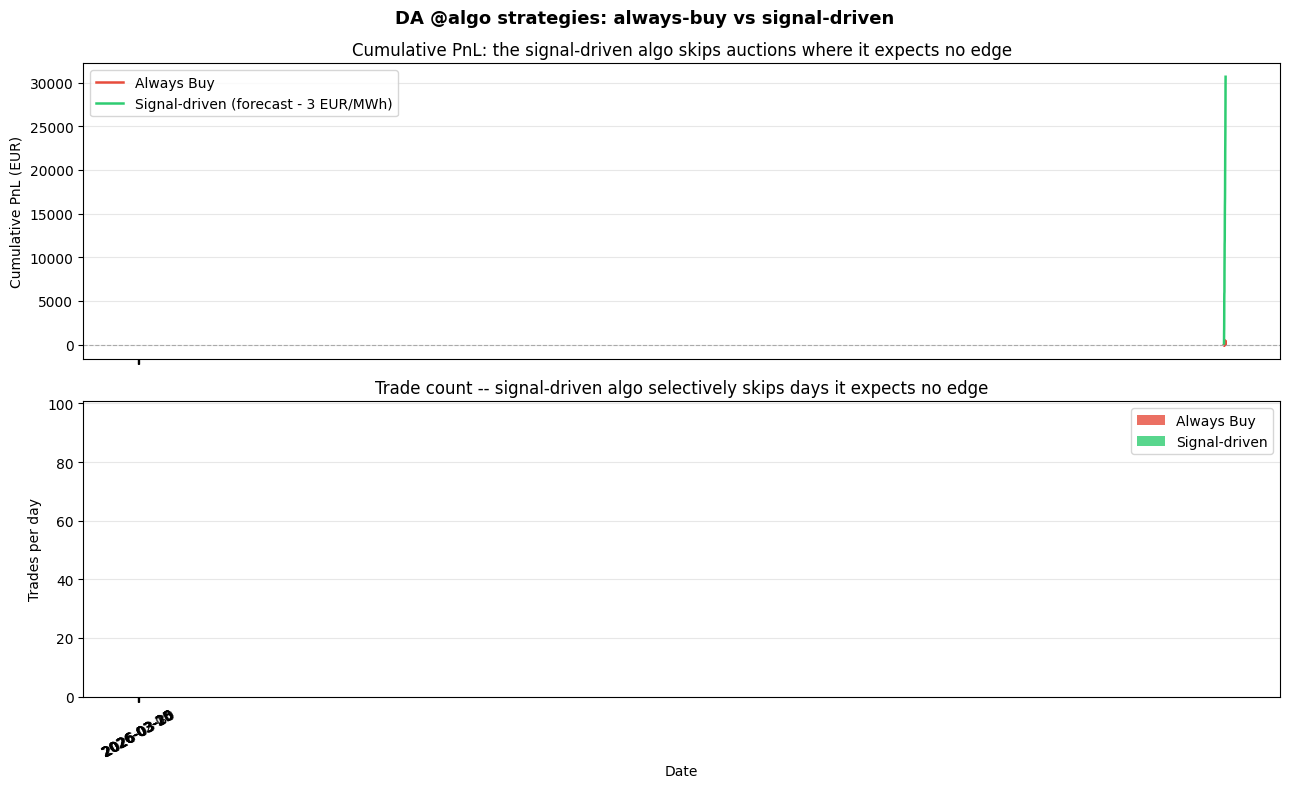


Strategy                            Fills   VWAP alpha (EUR)   Win rate
----------------------------------------------------------------------
Always Buy (@algo)                   2976              56.85      50.0%
Signal-driven (@algo)                 442           30667.20      97.3%


In [17]:
df_logger = da_result.daily_pnl_df()
df_signal = signal_result.daily_pnl_df()

df_logger = df_logger.copy()
df_signal = df_signal.copy()
df_logger["cumulative_pnl"] = df_logger["pnl"].cumsum()
df_signal["cumulative_pnl"] = df_signal["pnl"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle("DA @algo strategies: always-buy vs signal-driven", fontsize=13, fontweight="bold")

# -- Top: cumulative PnL -------------------------------------------------------
ax = axes[0]
ax.plot(df_logger["date"], df_logger["cumulative_pnl"],
        label="Always Buy", color="#e74c3c", linewidth=1.8)
ax.plot(df_signal["date"], df_signal["cumulative_pnl"],
        label="Signal-driven (forecast - 3 EUR/MWh)", color="#2ecc71", linewidth=1.8)
ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax.set_ylabel("Cumulative PnL (EUR)")
ax.set_title("Cumulative PnL: the signal-driven algo skips auctions where it expects no edge")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

# -- Bottom: daily trade count -------------------------------------------------
ax = axes[1]
dates = range(len(df_logger))
width = 0.38
ax.bar([d - width / 2 for d in dates], df_logger["trade_count"],
       width=width, label="Always Buy", color="#e74c3c", alpha=0.8)
ax.bar([d + width / 2 for d in dates], df_signal["trade_count"],
       width=width, label="Signal-driven", color="#2ecc71", alpha=0.8)
ax.set_ylabel("Trades per day")
ax.set_title("Trade count -- signal-driven algo selectively skips days it expects no edge")
ax.legend()
ax.grid(axis="y", alpha=0.3)

tick_step = 5
tick_pos = list(range(0, len(df_logger), tick_step))
ax.set_xticks(tick_pos)
ax.set_xticklabels(
    [str(df_logger.iloc[i]["date"])[:10] for i in tick_pos], rotation=30
)
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

print(f"\n{'Strategy':<32} {'Fills':>8} {'VWAP alpha (EUR)':>18} {'Win rate':>10}")
print("-" * 70)
print(f"{'Always Buy (@algo)':<32} {len(da_result.fills):>8} "
      f"{float(da_result.pnl.total_alpha_eur):>18.2f} "
      f"{float(da_result.pnl.buys.win_rate)*100:>9.1f}%")
print(f"{'Signal-driven (@algo)':<32} {len(signal_result.fills):>8} "
      f"{float(signal_result.pnl.total_alpha_eur):>18.2f} "
      f"{float(signal_result.pnl.buys.win_rate)*100:>9.1f}%")

## 10. State Management Patterns

`@algo` functions have no `self`. State lives in **local variables** declared before
the `async for` loop. This is simpler than class attributes for most strategies.

### Common patterns

```python
@algo(name="example", version="1.0.0")
async def run(ctx: TradingContext) -> None:

    # 1. Simple counters
    fill_count: int = 0

    # 2. Per-product sets -- e.g. gate closure tracking
    near_gate: set[str] = set()

    # 3. Per-product dictionaries -- e.g. last fill price, pending orders
    pending_order: dict[str, str] = {}          # product_id -> order_id
    last_fill_price: dict[str, Decimal] = {}    # product_id -> price

    # 4. Simple flags
    warmed_up: bool = False

    async for event in ctx.events():
        match event:
            case FillEvent(fill=fill):
                fill_count += 1
                last_fill_price[fill.product_id] = fill.price
```

### Extracting handlers to helper functions

For longer strategies, move event handling into module-level functions.
Helper functions are pure (take state as arguments) -- easy to unit test without the engine.

```python
def _handle_market_data(ctx, product_id, near_gate):
    ...

@algo(name="production_strategy", version="1.0.0")
async def run(ctx: TradingContext) -> None:
    near_gate: set[str] = set()

    async for event in ctx.events():
        match event:
            case MarketDataUpdate(product_id=pid):
                _handle_market_data(ctx, pid, near_gate)
```

This is the pattern used in `examples/async_spread_algo.py` in this repository.


## Summary

### Choose `@algo` when

- Your strategy needs to react to individual `MarketDataUpdate` events (not just MTU boundaries)
- You have cross-event logic (e.g. "only buy if spread was narrow in the last bar")
- You prefer a sequential top-down flow over scattered hook methods

### The `@algo` pattern at a glance

```python
from nexa_backtest.algo import algo
from nexa_backtest.context import TradingContext
from nexa_backtest.types import BarEvent, MarketDataUpdate, FillEvent, GateClosureWarning

@algo(name="my_algo", version="1.0.0")
async def run(ctx: TradingContext) -> None:
    near_gate: set[str] = set()   # initialise local state here
    fill_count = 0

    async for event in ctx.events():
        match event:
            case BarEvent(product_id=pid):           ...  # DA auction open or MTU tick
            case MarketDataUpdate(product_id=pid):   ...  # IDC order book change
            case FillEvent(fill=fill):               ...  # your order was matched
            case GateClosureWarning(product_id=pid): ...  # gate closing soon
            case GateClosureEvent(product_id=pid):   ...  # gate closed
            case CancelEvent(order_id=oid):          ...  # your order was cancelled

    ctx.log(f"Done. Total fills: {fill_count}")  # teardown after last event
```

### Key differences from `SimpleAlgo`

| | `SimpleAlgo` | `@algo` |
|--|--|--|
| DA auction trigger | `on_auction_open(auction)` | `BarEvent` |
| Signal access | `subscribe_signal()` + `on_signal` hook | `ctx.get_signal("name")` anywhere |
| Per-event order book | Not available | `MarketDataUpdate` on every book change |
| State | `self.*` instance attributes | Local variables |

### Further reading

- `examples/async_spread_algo.py` -- complete reference implementation in this repo
- `notebooks/idc_and_metrics_walkthrough.ipynb` -- IDC matching mechanics
- `src/nexa_backtest/types.py` -- full event type definitions
